In [35]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import json
import string
import glob
import matplotlib.lines as mlines

from matplotlib.ticker import FormatStrFormatter
from sklearn.metrics import adjusted_mutual_info_score as AMI
from matplotlib.patches import Patch
import nmi
from helps import *

# SuppFig1

## Data

In [ ]:
metadata=pd.DataFrame()
shapes={}
for file in sorted(glob.glob("Datasets/*/CM/*GEX_Raw.h5ad")):
	if "Neuroblastoma" not in file:
		print(file)
		adata=sc.read_h5ad(file)
		obs=pd.DataFrame(adata.obs["CellType"])
		dataset=file.split("/")[1]
		print(dataset)
		obs["Dataset"]=dataset
		shapes[dataset]=adata.shape
		metadata=pd.concat([metadata, obs])
with open('Tables/shapes.json', 'w') as f:
	json.dump(shapes, f)
metadata.to_csv("Tables/Metadata.tsv.gz", sep="\t", compression="gzip")

In [ ]:
data=pd.DataFrame(columns=["Dataset","Omic","Size"])
for omic in ["Peak","ADT","mRNA","lncRNA","GEX"]:
	if "Neuroblastoma" not in file:
		print(omic)
		files=sorted(glob.glob(f"../Datasets/*/CM/*{omic}_Raw.h5ad"))
		for file in files:
			adata=sc.read_h5ad(file)
			ds=file.split("/")[2]
			d=pd.DataFrame([ds, omic, adata.shape[1]], index=data.columns).T
			data=pd.concat([data,d])
data=data[data["Dataset"]!="Neuroblastoma"]
data

In [ ]:
data.to_csv("Tables/Metadata_features_size.tsv.gz", sep="\t", compression="gzip")

## Figure

In [ ]:
metadata=pd.read_csv("Tables/Metadata.tsv.gz", sep="\t", index_col=0)
data=pd.read_csv("Tables/Metadata_features_size.tsv.gz", sep="\t", index_col=0)
with open('Tables/shapes.json') as f:
	shapes = json.load(f)
cts={}
for ds in sorted(set(metadata["Dataset"])):
	d=metadata[metadata["Dataset"]==ds]
	cts[ds]=len(set(d["CellType"]))
mains=data[(data["Omic"]=="Peak") ^ (data["Omic"]=="ADT")][["Dataset","Size"]].set_index("Dataset")#.to_dict()["Size"]
gexs=data[data["Omic"]=="GEX"][["Dataset","Size"]].set_index("Dataset")#.to_dict()["Size"]
mrnas=data[data["Omic"]=="mRNA"][["Dataset","Size"]].set_index("Dataset")#.to_dict()["Size"]
lncrnas=data[data["Omic"]=="lncRNA"][["Dataset","Size"]].set_index("Dataset")#.to_dict()["Size"]

In [ ]:
tot=pd.concat([pd.DataFrame.from_dict(cts, orient="index"), mains,gexs, mrnas, lncrnas], axis=1)
tot.columns=["Number of cell types","Number of peaks or surface moelecules", "Number of genes","Number of mRNAs", "Number of lncRNAs"]
tot.to_csv("Tables/SuppTable1.tsv", sep="\t")

In [ ]:
mains=data[(data["Omic"]=="Peak") ^ (data["Omic"]=="ADT")][["Dataset","Size"]].set_index("Dataset").to_dict()["Size"]
gexs=data[data["Omic"]=="GEX"][["Dataset","Size"]].set_index("Dataset").to_dict()["Size"]
mrnas=data[data["Omic"]=="mRNA"][["Dataset","Size"]].set_index("Dataset").to_dict()["Size"]
lncrnas=data[data["Omic"]=="lncRNA"][["Dataset","Size"]].set_index("Dataset").to_dict()["Size"]

fig, axs = plt.subplots(1,3, dpi=300, figsize=(15,5))
axs=axs.flatten()

x=np.log10(np.array(list(shapes.values())).T[0])
y=[cts[key] for key in shapes.keys()]
axs[0].scatter(x=x, y=y)
for i, label in enumerate(shapes.keys()):
	axs[0].annotate(
		label, 
		(x[i], y[i]),			  # point position
		textcoords="offset points", 
		xytext=(-7,5),			  # offset text position
		ha='left', fontsize=8,
		arrowprops=dict(arrowstyle="->", color="gray", lw=0.5))
axs[0].set_xlabel("Number of cells [log10(count)]", size=13)
axs[0].set_ylabel("Number of cell types [count]", size=13)

x=np.log10(list(gexs.values()))
y=np.log10([mains[key] for key in gexs.keys()])
axs[1].scatter(x=x, y=y)
for i, label in enumerate(gexs.keys()):
	axs[1].annotate(
		label, 
		(x[i], y[i]),			  # point position
		textcoords="offset points", 
		xytext=(-7,5),			  # offset text position
		ha='left', fontsize=8,
		arrowprops=dict(arrowstyle="->", color="gray", lw=0.5))
axs[1].set_xlabel("Number of genes [log10(count)]", size=13)
axs[1].set_ylabel("Number of peaks or\nsurface proteins [log10(count)]", size=13)

x=np.log10(list(mrnas.values()))
y=np.log10([lncrnas[key] for key in mrnas.keys()])
axs[2].scatter(x=x, y=y)
for i, label in enumerate(mrnas.keys()):
	axs[2].annotate(
		label, 
		(x[i], y[i]),			  # point position
		textcoords="offset points", 
		xytext=(-7,5),			  # offset text position
		ha='left', fontsize=8,
		arrowprops=dict(arrowstyle="->", color="gray", lw=0.5))
axs[2].set_xlabel("Number of mRNAs [log10(count)]", size=13)
axs[2].set_ylabel("Number of lncRNAs [log10(count)]", size=13)

for i, ax in enumerate(axs):
	ax.spines['top'].set_visible(False)
	ax.spines['right'].set_visible(False)
	ax.text(-0.075, 1.05, string.ascii_uppercase[i], transform=ax.transAxes, size=20, weight='bold',rotation=0)  

plt.tight_layout(w_pad=1.5)
plt.savefig("Figures/SuppFig1.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

# SuppFig2

## Data

In [ ]:
cm="Datasets/PBMC/CM/PBMC_Peak_GEX_Def.h5mu"
path_to_save="Datasets/PBMC/Mowgli/MLD"

In [ ]:
os.system(f"sbatch -p slim18 -J MowLT --mem=64G --ntasks=1 --cpus-per-task=10 \
		--output=Datasets/PBMC/PBMC_Mowgli_LatentDim_Peak_GEX.out Run_Exp.sh Mowgli_LatentDim {cm} {path_to_save}")

In [ ]:
cm="Datasets/PBMC/CM/PBMC_Peak_GEX_Def.h5mu"
path_to_save="Datasets/PBMC/ShareTopic/STLD"

In [ ]:
os.system(f"sbatch -p slim18 -J ShTLT --mem=64G --ntasks=1 --cpus-per-task=10 \
		--output=Datasets/PBMC/PBMC_ShareTopic_LatentDim_Peak_GEX.out Run_Exp.sh ShareTopic_LatentDim {cm} {path_to_save}")

In [ ]:
df=pd.DataFrame(columns=["LT", "Run","NMI","NMI*","Method"])
for latent_dim in [2,6,12,18,24]:
	for run in range(0, 5):
		print(latent_dim, run)
		file_data=f"Datasets/PBMC/Mowgli/LatentDim/LT_{latent_dim}/Run{run}/MLD_Embedding.tsv.gz"
		if os.path.isfile(file_data):
			temp=pd.read_csv(file_data, index_col=0, sep="\t")
			metadata=pd.DataFrame(mdata["Peak"].obs["CellType"])
			data=pd.DataFrame([temp.columns, np.argmax(temp, axis=0).astype(str)]).T
			data.rename({0 : "cell", 1 : "cluster"}, axis=1, inplace=True)
			data.set_index("cell", inplace=True)
			inter=intersection([data.index, metadata.index])
			metadata=metadata.loc[inter]
			data=data.loc[inter]
			NMI=nmi.compute_normalised_mutual_information(metadata["CellType"], data["cluster"])
			nmi_rand=0
			for k in range(100):
				a=data["cluster"].to_list()
				np.random.shuffle(a)
				nmi_rand+=nmi.compute_normalised_mutual_information(metadata["CellType"], a)/100
			d=pd.DataFrame([latent_dim, run, NMI, nmi_rand, "Mowgli"], index=df.columns).T
			df=pd.concat([df, d])

		file_data=f"Datasets/PBMC/ShareTopic/LatentDim/LT_{latent_dim}/Run{run}/STLD_MaxTopic.tsv.gz"
		if os.path.isfile(file_data):
			data=pd.read_csv(file_data, sep="\t", index_col=0, names=["cluster"])
			metadata=pd.DataFrame(mdata["Peak"].obs["CellType"])
			inter=intersection([data.index, metadata.index])
			metadata=metadata.loc[inter]
			data=data.loc[inter]
			NMI=nmi.compute_normalised_mutual_information(metadata["CellType"], data["cluster"])
			nmi_rand=0
			for k in range(100):
				a=data["cluster"].to_list()
				np.random.shuffle(a)
				nmi_rand+=nmi.compute_normalised_mutual_information(metadata["CellType"], a)/100
			d=pd.DataFrame([latent_dim, run, NMI, nmi_rand,"ShareTopic"], index=df.columns).T
			df=pd.concat([df, d])
df["NMI/NMI*"]=(df["NMI"]/df["NMI*"]).astype(float)
df["log10(NMI/NMI*)"]=np.log10(df["NMI/NMI*"].astype(float))
df["LT"]=df["LT"].astype(int)
df["NMI"]=df["NMI"].astype(float)
df["NMI"]=df["NMI"].astype(float)
df.reset_index().drop("index", axis=1, inplace=True)
df.to_csv("Tables/NMI_vs_LatentDim.tsv.gz", sep="\t", compression="gzip")

## Figure

In [ ]:
df=pd.read_csv("Tables/NMI_vs_LatentDim.tsv.gz", sep="\t", index_col=0)
df.head()

In [ ]:
palette={alg : colors_to_use_pastel[i] for i,alg in enumerate(["ShareTopic","Mowgli"])}
fig, axs = plt.subplots(1,3, figsize=(17,5), dpi=300)
axs=axs.flatten()
sns.stripplot(data=df, x="LT", y="log10(NMI/NMI*)", ax=axs[0], hue="Method", palette=palette, dodge=True, size=10)
sns.stripplot(data=df, x="LT", y="NMI", ax=axs[1], hue="Method", palette=palette, dodge=True, size=10)
sns.stripplot(data=df, x="LT", y="NMI*", ax=axs[2], hue="Method", palette=palette, dodge=True, size=10)
for ax in axs:
	ax.legend().remove()

for l, label in enumerate(["log10(NMI/NMI*)","NMI", "NMI*"]):
	mymax = 1 if label == "NMI" else np.max(df[label])
	axs[l].set_ylim([0, mymax])
	axs[l].vlines(x="12", ymin=0, ymax=mymax, color='red', zorder=1, linestyle="--")
	axs[l].spines['top'].set_visible(False)
	axs[l].spines['right'].set_visible(False)  
	axs[l].spines['bottom'].set_visible(True)
	axs[l].spines['left'].set_visible(True)  
	axs[l].set_xlabel("Number of topics")
	axs[l].text(-0.075, 1.05, string.ascii_uppercase[l], transform=axs[l].transAxes, size=20, weight='bold',rotation=0)  
axs[1].set_ylim([0,1])
handles=[]
for key in palette.keys():
	handles.append(mlines.Line2D([], [], color=palette[key], marker='o', linestyle='None', markersize=10, label=key))
axs[2].legend(handles=handles, bbox_to_anchor=(1.7, 0.5), title="Method", fontsize=17, title_fontsize=20)

plt.tight_layout(w_pad=1.5)
plt.savefig("Figures/SuppFig2.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

# SuppFig3

## Data

In [4]:
os.system(f"sbatch -p slim18 -J nSBMres --mem=64G --ntasks=1 --cpus-per-task=10 --exclusive \
		--output=bionSBM_resources.out Run_Exp.sh bionSBM_Resources")

os.system(f"sbatch -p slim18 -J Mowres --mem=64G --ntasks=1 --cpus-per-task=10 --exclusive \
		--output=Mowgli_resources.out Run_Exp.sh Mowgli_Resources")

os.system(f"sbatch -p slim18 -J BIOvsN --mem=64G --ntasks=1 --cpus-per-task=8 --exclusive \
		--output=Graph_creation_bionsbm_vs_nSBM.out Run_Exp.sh GraphCreation_SBMs")

Submitted batch job 1450700


0

In [9]:
os.system("cat bionSBM_resources.out")

Starting with 500
2025-11-28 10:40:28,983 - INFO - Creating graph from multiple DataFrames
2025-11-28 10:40:29,107 - INFO - Building graph with 500 docs and 28195 words
2025-11-28 10:40:30,757 - INFO - Saving graph to results/myself_graph.xml.gz
2025-11-28 10:40:31,515 - INFO - Fit number: 0


0

In [24]:
os.system(f"sbatch -p slim18 -J ShTores --mem=64G --ntasks=1 --cpus-per-task=10 --exclusive \
		--output=ShareTopic_resources.out Run_Exp.sh ShareTopic_Resources")

Submitted batch job 1450762


0

In [38]:
nsb=pd.read_csv("Tables/Time_bionSBM_vs_nSBM_cells.tsv", sep="\t")
bio=pd.read_csv("Tables/Time_bionSBM_cells.tsv", sep="\t")
mow=pd.read_csv("Tables/Time_Mowgli_cells.tsv", sep="\t")
share=pd.read_csv("Tables/Time_ShareTopic_cells.tsv", sep="\t")
biobio=pd.read_csv("Tables/Time_bionSBM_cells.tsv", sep="\t")

In [39]:
# --- Models (your style) ---
def linear(x, a, b):
    return a * x + b
# Exponential: y = a * exp(b * x)
def exp_model(x, a, b):
    return a * np.exp(b * x)

def fit_all(x, y):
    x = np.asarray(x, int)
    y = np.asarray(y, float)

    # Linear (curve_fit)
    popt_lin, _ = curve_fit(linear, x, y)
    y_lin = linear(x, *popt_lin)
    r2_lin = r2_score(y, y_lin)


    # Exponential (log-space)
    mask = y > 0
    if mask.sum() >= 2:
        coeff = np.polyfit(x[mask], np.log(y[mask]), 1)  # log(y) = b*x + log(a)
        b_exp = coeff[0]
        a_exp = np.exp(coeff[1])
        y_exp = exp_model(x, a_exp, b_exp)
        r2_exp = r2_score(y, y_exp)
    else:
        a_exp = b_exp = np.nan
        y_exp = np.full_like(y, np.nan, dtype=float)
        r2_exp = np.nan

    return {
        "linear":     {"params": popt_lin,         "yhat": y_lin,  "r2": r2_lin},
        "exponential":{"params": (a_exp, b_exp),   "yhat": y_exp,  "r2": r2_exp}}

In [40]:
palette={alg : colors_to_use_pastel[i] for i,alg in enumerate(["ShareTopic","Mowgli","bionSBM","nSBM"])}

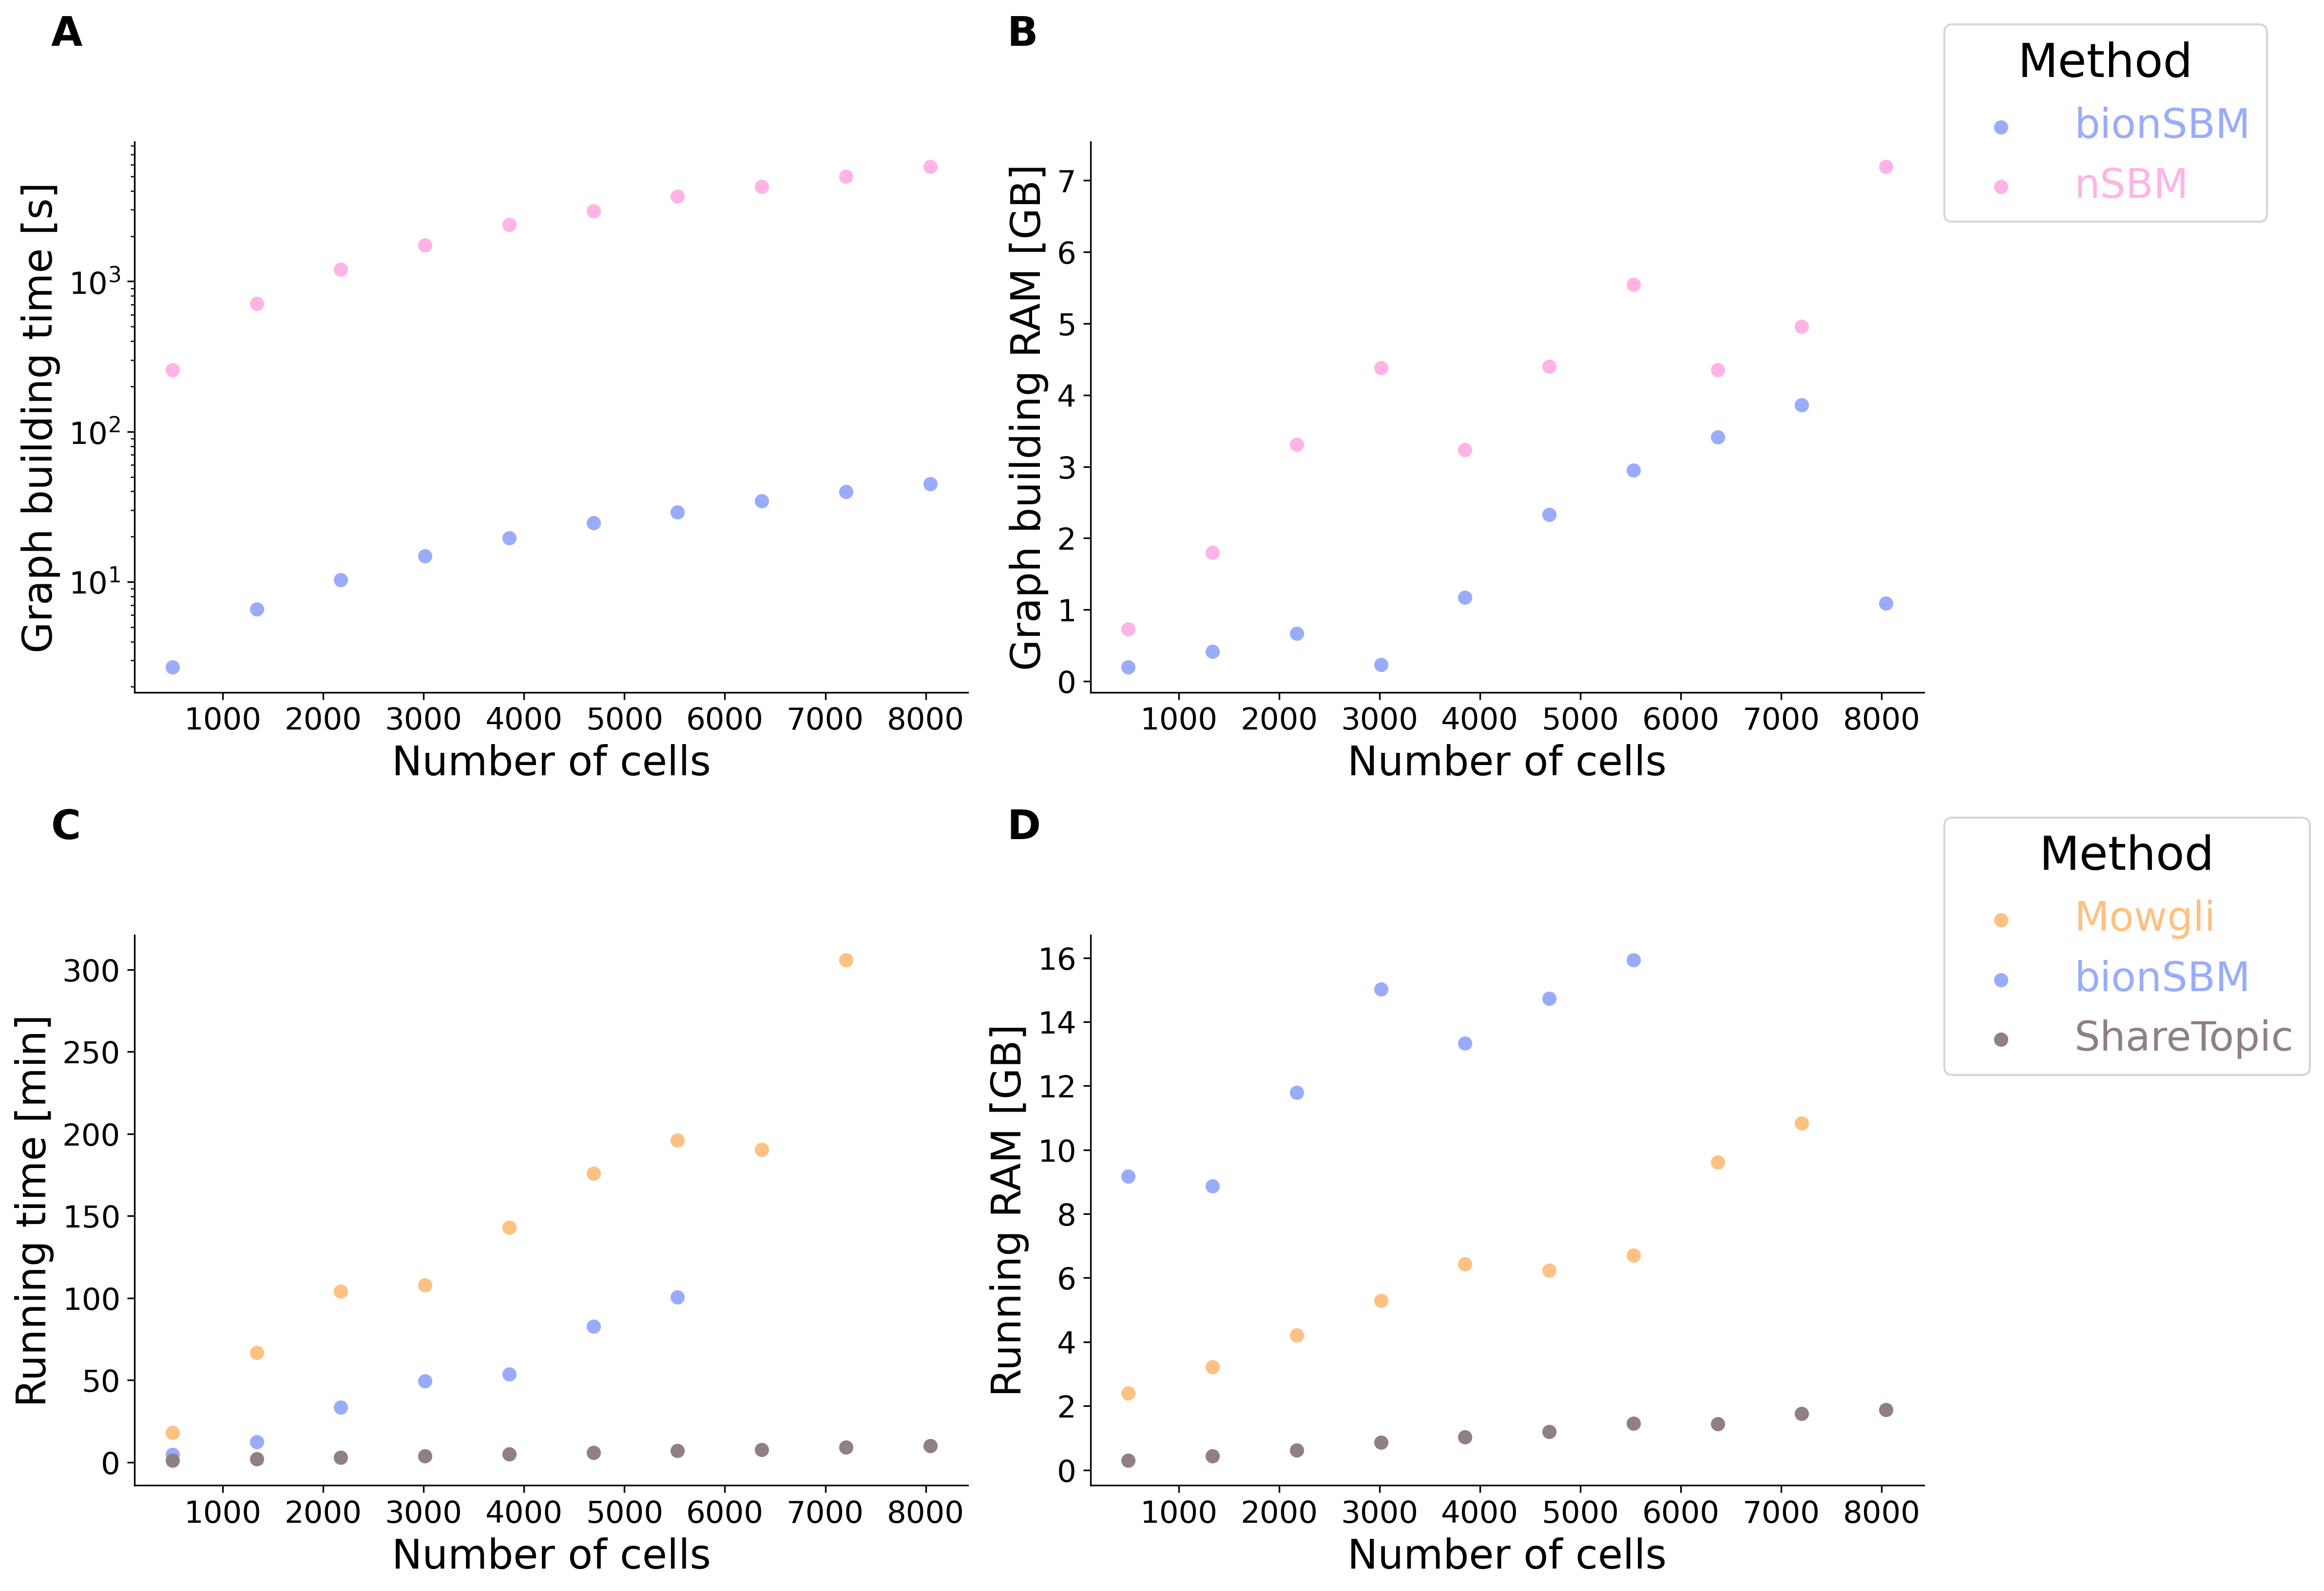

In [44]:
params = {'axes.labelsize': 20,
         'axes.titlesize': 20,
         'xtick.labelsize' : 15,
         'ytick.labelsize': 15,
         "lines.linewidth" : 4,
         "figure.dpi" : 300,
         "figure.figsize": [16, 11]}
plt.rcParams.update(params)

fig, axs = plt.subplots(2,2)
axs=axs.flatten()

axs[0].scatter(x=nsb["n_cells"], y=nsb["t_bionsbm"], label="bionSBM", color=palette["bionSBM"])
axs[0].scatter(x=nsb["n_cells"], y=nsb["t_nsbm"], label="nSBM", color=palette["nSBM"])
axs[0].set_yscale("log")
axs[0].set_ylabel("Graph building time [s]")

axs[1].scatter(x=nsb["n_cells"], y=nsb["ram_bionsbm"], label="bionSBM", color=palette["bionSBM"])
axs[1].scatter(x=nsb["n_cells"], y=nsb["ram_nsbm"], label="nSBM", color=palette["nSBM"])
axs[1].set_ylabel("Graph building RAM [GB]")
handles, labels = axs[1].get_legend_handles_labels()
axs[1].legend(handles, labels, bbox_to_anchor=(1, 1.25), title="Method", 
              fontsize=20, title_fontsize=23, labelcolor=[palette[key] for key in labels]) 


axs[2].scatter(x=mow["n_cells"], y=mow["t_mowgli"]/60, label="Mowgli", color=palette["Mowgli"])
axs[2].scatter(x=bio["n_cells"], y=bio["t_bionsbm"]/60, label="bionSBM", color=palette["bionSBM"])
axs[2].scatter(x=share["n_cells"], y=share["t_sharetopic"]/60, label="ShareTopic", color=palette["ShareTopic"])
axs[2].set_ylabel("Running time [min]")

axs[3].scatter(x=mow["n_cells"], y=mow["ram_mowgli"], label="Mowgli", color=palette["Mowgli"])
axs[3].scatter(x=bio["n_cells"], y=bio["ram_bionsbm"], label="bionSBM", color=palette["bionSBM"])
axs[3].scatter(x=share["n_cells"], y=share["ram_sharetopic"], label="ShareTopic", color=palette["ShareTopic"])
axs[3].set_ylabel("Running RAM [GB]")
handles, labels = axs[3].get_legend_handles_labels()
axs[3].legend(handles, labels, bbox_to_anchor=(1, 1.25), title="Method", 
              fontsize=20, title_fontsize=23, labelcolor=[palette[key] for key in labels]) 

for l, ax in enumerate(axs):
    axs[l].spines['top'].set_visible(False)
    axs[l].spines['right'].set_visible(False)  
    axs[l].spines['bottom'].set_visible(True)
    axs[l].spines['left'].set_visible(True)  
    axs[l].set_xlabel("Number of cells")
    axs[l].text(-0.1, 1.175, string.ascii_uppercase[l], transform=axs[l].transAxes, size=20, weight='bold',rotation=0)  

plt.tight_layout()
plt.show()